# Ensemble — DenseNet121 + EfficientNet-B7
Este notebook carrega dois modelos já treinados e combina as suas probabilidades por média simples (soft voting) para obter um F1-score superior ao de qualquer modelo individual.

## Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import seaborn as sns
import torch
import torch.nn as nn
import torchvision.models as tv

from monai.networks.nets import DenseNet121
from monai.transforms import (
    LoadImage, EnsureChannelFirst, Resize,
    ToTensor, Compose, NormalizeIntensity, Lambda
)
from monai.data import DataLoader
from monai.utils import set_determinism

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, f1_score
)
from torch.utils.data import Dataset

np.random.seed(42)
set_determinism(seed=42)
random.seed(42)
torch.manual_seed(42)

c:\Users\carlo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## Caminhos

In [3]:
base_dir           = './dataset'
model_densenet     = './models/MIA_AP_my_models/densenet_v99_20260509_161534.pth'
model_efficientnet = './models/efficientnet_b7.pth'

## Dataset

In [4]:
phases = ['train', 'val', 'test']
data   = {phase: {'images': [], 'labels': []} for phase in phases}

class_names = sorted([
    x for x in os.listdir(os.path.join(base_dir, 'train'))
    if os.path.isdir(os.path.join(base_dir, 'train', x))
])
num_class = len(class_names)
print(f"Classes ({num_class}): {class_names}")

def load_images_labels(phase):
    valid_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, phase, class_name)
        image_files = [
            os.path.join(class_dir, x)
            for x in os.listdir(class_dir)
            if x.lower().endswith(valid_exts)
        ]
        data[phase]['images'].extend(image_files)
        data[phase]['labels'].extend([i] * len(image_files))

for phase in phases:
    load_images_labels(phase)

for phase in phases:
    print(f"{phase.capitalize()} count = {len(data[phase]['images'])}")

Classes (4): ['Biliary_Leaks', 'Lithiasis', 'Normal', 'Stricture']
Train count = 1067
Val count = 234
Test count = 267


## Transforms e DataLoader (teste)

In [5]:
def repeat_if_needed(img):
    if img.shape[0] == 1:
        return img.repeat(3, 1, 1)
    return img

class EnsureSingleChannel:
    def __call__(self, img):
        if img.shape[0] == 3:
            img = img.mean(dim=0, keepdim=True)
        return img

val_transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),
    Resize((512, 512)),
    NormalizeIntensity(),
    Lambda(repeat_if_needed),
    ToTensor()
])

class MedNISTDataset(Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels      = labels
        self.transforms  = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]

test_ds     = MedNISTDataset(data['test']['images'], data['test']['labels'], val_transforms)
test_loader = DataLoader(test_ds, batch_size=16, num_workers=0)
print(f"Test batches: {len(test_loader)}")

Test batches: 17


## Carregar modelos

Cada modelo é reconstruído com a mesma arquitetura usada no treino e depois os pesos guardados são carregados.

In [6]:
# ── DenseNet121 (MONAI) ──────────────────────────────────────────────────────
densenet_model = DenseNet121(
    spatial_dims=2,
    in_channels=3,
    out_channels=num_class,
    pretrained=False          # pesos vêm do .pth
).to(device)

state_dict = torch.load(model_densenet, map_location=device)
densenet_model.load_state_dict(state_dict)
densenet_model.eval()
print("DenseNet121 carregado.")

# ── EfficientNet-B7 (torchvision) ────────────────────────────────────────────
efficientnet_model = tv.efficientnet_b7(weights=None)
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features, num_class
)
efficientnet_model = efficientnet_model.to(device)
efficientnet_model.load_state_dict(
    torch.load(model_efficientnet, map_location=device, weights_only=False)
)
efficientnet_model.eval()
print("EfficientNet-B7 carregado.")

DenseNet121 carregado.
EfficientNet-B7 carregado.


## Ensemble — soft voting (média de probabilidades)

In [7]:
def ensemble_predict(models, dataloader, device):
    """Soft voting: média das probabilidades de todos os modelos."""
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            probs_list = []
            for model in models:
                model.eval()
                out = torch.softmax(model(inputs), dim=1)
                probs_list.append(out)

            # Média das probabilidades de todos os modelos
            avg_probs = torch.stack(probs_list).mean(dim=0)
            preds     = avg_probs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

## Avaliação — modelos individuais vs ensemble

In [8]:
def evaluate_single(model, dataloader, device):
    """Avalia um único modelo no dataloader."""
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            out    = model(inputs)
            preds  = out.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

# Modelos individuais
print("=" * 55)
for name, model in [
    ('DenseNet121',     densenet_model),
    ('EfficientNet-B7', efficientnet_model),
]:
    y_true, y_pred = evaluate_single(model, test_loader, device)
    f1  = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"{name:<18}  F1={f1:.4f}   Acc={acc:.4f}")

# Ensemble
print("=" * 55)
# models_ensemble = [densenet_model, efficientnet_model, resnet_model]
models_ensemble = [densenet_model, efficientnet_model]
actual, predictions = ensemble_predict(models_ensemble, test_loader, device)
f1_ens  = f1_score(actual, predictions, average='macro')
acc_ens = accuracy_score(actual, predictions)
print(f"{'ENSEMBLE':<18}  F1={f1_ens:.4f}   Acc={acc_ens:.4f}")
print("=" * 55)

DenseNet121         F1=0.4228   Acc=0.5393
EfficientNet-B7     F1=0.7381   Acc=0.7828
ENSEMBLE            F1=0.7130   Acc=0.7640


## Relatório detalhado — Ensemble

In [9]:
print(classification_report(
    actual, predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
))

               precision    recall  f1-score   support

Biliary_Leaks     0.8750    0.4118    0.5600        17
    Lithiasis     0.8571    0.7317    0.7895       123
       Normal     0.4940    0.9535    0.6508        43
    Stricture     0.9296    0.7857    0.8516        84

     accuracy                         0.7640       267
    macro avg     0.7889    0.7207    0.7130       267
 weighted avg     0.8226    0.7640    0.7721       267



## Confusion Matrix — Ensemble

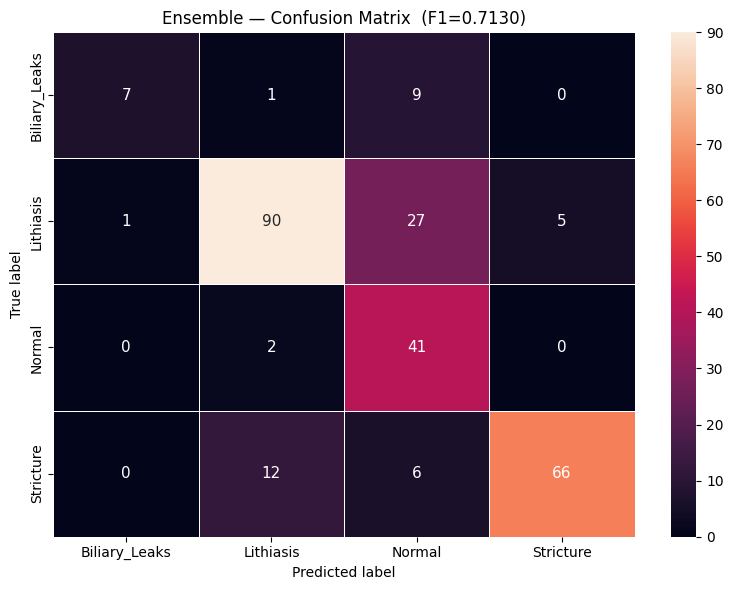

Confusion matrix guardada em ./models/ensemble_cm.png


In [10]:
cm = confusion_matrix(actual, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    annot_kws={'size': 11}
)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title(f'Ensemble — Confusion Matrix  (F1={f1_ens:.4f})')
plt.tight_layout()
plt.savefig('./models/ensemble_cm.png', dpi=300)
plt.show()
print("Confusion matrix guardada em ./models/ensemble_cm.png")

## (Opcional) Ensemble sem DeiT — comparação rápida

O DeiT obteve F1=0.158 no artigo, pelo que prejudica o ensemble. Esta célula mostra o resultado sem ele (já é o caso acima), mas serve de referência caso queiras testar outras combinações de modelos.

In [11]:
# Experimenta subconjuntos de modelos
combos = {
    'DenseNet_v99 + EfficientNet':          [densenet_model, efficientnet_model],
}

print(f"{'Combinação':<40}  F1 (macro)")
print("-" * 55)
for label, models in combos.items():
    y_true, y_pred = ensemble_predict(models, test_loader, device)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"{label:<40}  {f1:.4f}")

Combinação                                F1 (macro)
-------------------------------------------------------
DenseNet_v99 + EfficientNet               0.7130
